In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

TRAIN_JSON = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\data\processed_json\train.json"
VAL_JSON   = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\data\processed_json\val.json"
TEST_JSON  = r"C:\Users\Nandita\Downloads\End-to-End-Deep-Learning-for-Autonomous-Driving\data\processed_json\test.json"

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

train = load_json(TRAIN_JSON)
val   = load_json(VAL_JSON)
test  = load_json(TEST_JSON)

print(f"Train samples: {len(train)}")
print(f"Val samples:   {len(val)}")
print(f"Test samples:  {len(test)}")


Train samples: 6997
Val samples:   1499
Test samples:  1501


In [3]:
#Convert to DataFrame

df_train = pd.DataFrame(train)
df_val   = pd.DataFrame(val)
df_test  = pd.DataFrame(test)

df_train.head()


,image_front_right,image_front,image_front_left,seg_front,boxes,box_labels,velocity_x,velocity_y,velocity_z,speed_kmh,throttle,steer,brake,nearest_object_dist,box_count
0,data/hf_data\images\2402_front_right.png,data/hf_data\images\2402_front.png,data/hf_data\images\2402_left.png,data/hf_data\images\2402_seg_front.png,[],[],-0.009135,-1.937156,0.548462,7.247962,0.850000,-0.009159,0.0,9999.000000,0
1,data/hf_data\images\4014_front_right.png,data/hf_data\images\4014_front.png,data/hf_data\images\4014_left.png,data/hf_data\images\4014_seg_front.png,"[[313.90869140625, 306.52142333984375, 329.634...","[vehicle, vehicle]",8.255993,0.134148,0.023541,29.725618,0.109416,0.003830,0.0,130.158008,2
2,data/hf_data\images\988_front_right.png,data/hf_data\images\988_front.png,data/hf_data\images\988_left.png,data/hf_data\images\988_seg_front.png,"[[237.560546875, 304.4198303222656, 250.088806...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",0.000000,0.000000,0.000000,0.000000,0.000000,-0.167606,1.0,83.772867,13
3,data/hf_data\images\4626_front_right.png,data/hf_data\images\4626_front.png,data/hf_data\images\4626_left.png,data/hf_data\images\4626_seg_front.png,"[[0.0, 161.9890594482422, 290.5579833984375, 4...","[vehicle, vehicle, vehicle, vehicle, vehicle]",0.000000,0.000000,0.000000,0.000000,0.000000,-0.070127,1.0,89.834725,5
4,data/hf_data\images\7134_front_right.png,data/hf_data\images\7134_front.png,data/hf_data\images\7134_left.png,data/hf_data\images\7134_seg_front.png,"[[249.60365295410156, 305.7678527832031, 264.6...","[vehicle, vehicle, vehicle, vehicle, vehicle, ...",0.000032,0.001235,0.008557,0.031124,0.000000,-0.212528,1.0,81.847457,16


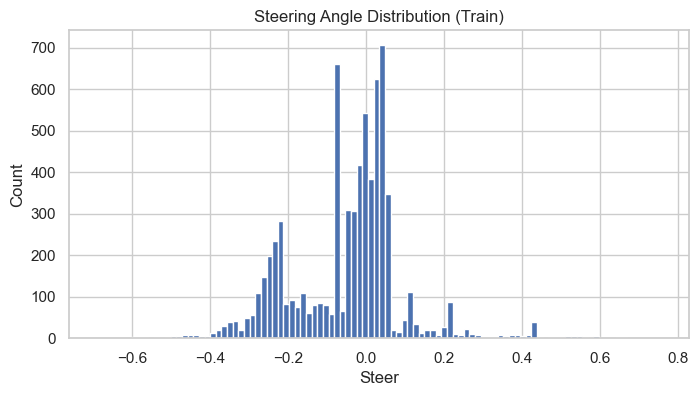

In [5]:
#Convert to DataFrame

plt.figure(figsize=(8,4))
plt.hist(df_train["steer"], bins=100)
plt.title("Steering Angle Distribution (Train)")
plt.xlabel("Steer")
plt.ylabel("Count")
plt.show()


In [9]:
# Brake analysis

plt.figure(figsize=(6,4))
df_train["brake_binary"].value_counts().plot(kind="bar")
plt.title("Brake Binary Distribution")
plt.xticks(rotation=0)
plt.show()

#To validates your brake logic
sns.scatterplot(
    x=df_train["nearest_object_dist"],
    y=df_train["speed_kmh"],
    hue=df_train["brake_binary"],
    alpha=0.4
)
plt.title("Braking vs Distance & Speed")
plt.show()

KeyError: 'brake_binary'

<Figure size 600x400 with 0 Axes>

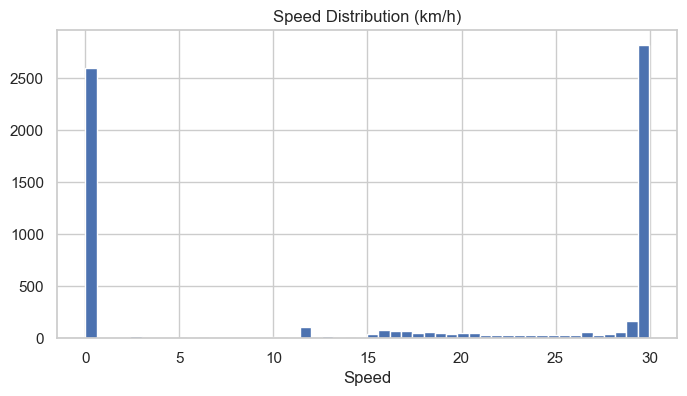

In [11]:
# Speed distribution

plt.figure(figsize=(8,4))
plt.hist(df_train["speed_kmh"], bins=50)
plt.title("Speed Distribution (km/h)")
plt.xlabel("Speed")
plt.show()

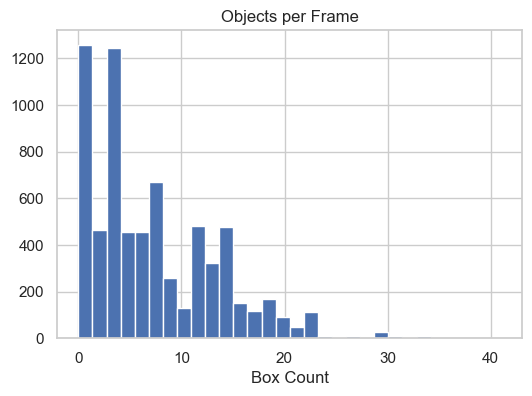

In [13]:
# Bounding box statistics

df_train["box_count"] = df_train["boxes"].apply(len)

plt.figure(figsize=(6,4))
plt.hist(df_train["box_count"], bins=30)
plt.title("Objects per Frame")
plt.xlabel("Box Count")
plt.show()


In [ ]:
# Nearest object distance

plt.figure(figsize=(6,4))
plt.hist(df_train["nearest_object_dist"], bins=50)
plt.title("Nearest Object Distance (px)")
plt.show()

In [15]:
# Visual sanity check
import cv2
import random

def show_sample(row):
    img = cv2.imread(row["image_front"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for box in row["boxes"]:
        x1,y1,x2,y2 = map(int, box)
        cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

    plt.figure(figsize=(6,4))
    plt.imshow(img)
    plt.title(f"Steer={row['steer']:.3f} | Speed={row['speed_kmh']:.1f}")
    plt.axis("off")
    plt.show()

sample = df_train.sample(1).iloc[0]
show_sample(sample)



error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


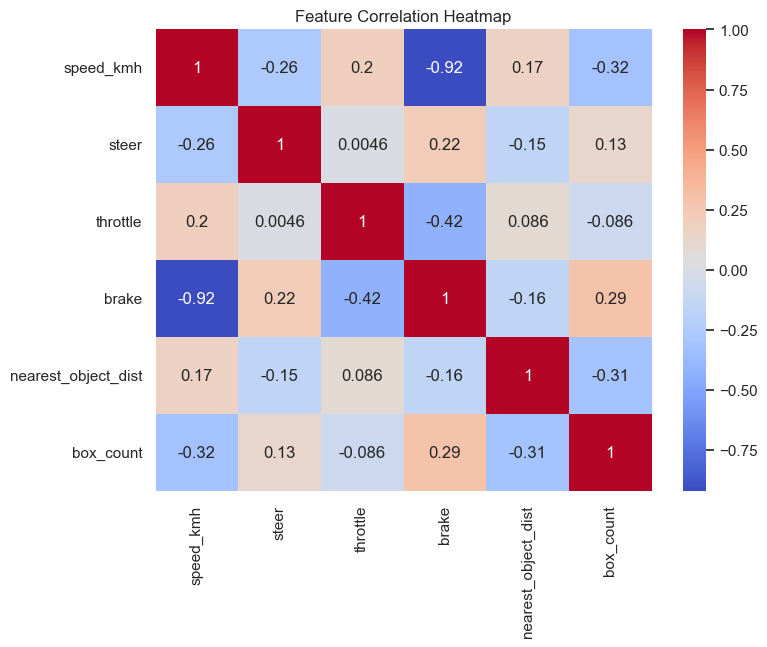

In [17]:
# Correlations

features = [
    "speed_kmh", "steer", "throttle",
    "brake", "nearest_object_dist", "box_count"
]

plt.figure(figsize=(8,6))
sns.heatmap(df_train[features].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()